#**Healthcare Data Science Project**

---



---



##*“This project focuses on predicting diabetes using patient health data. The goal is to build a reliable classification model that can help identify individuals at risk. Since this is a healthcare problem, special attention is given to recall to minimize missed diagnoses.”*

- **Data Loading & Initial Setup**

---






In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
           "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]

df = pd.read_csv(url, names=columns)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


- **DATA OVERVIEW**

---



In [2]:
# Understanding The Data

df.shape

(768, 9)

In [3]:
#It will show data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
(df == 0).sum()

,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,500


- **DATA CLEANING**

---



In [6]:
#Converting  0 into NaN
import numpy as np
cols_tofix = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[cols_tofix] = df[cols_tofix].replace(0, np.nan)

In [7]:
#Checking missing values
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [8]:
#filling missing values
df.fillna(df.median(), inplace = True)

In [9]:
#Verify Cleaning
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


- **EXPLORATORY DATA ANALYSIS**

---



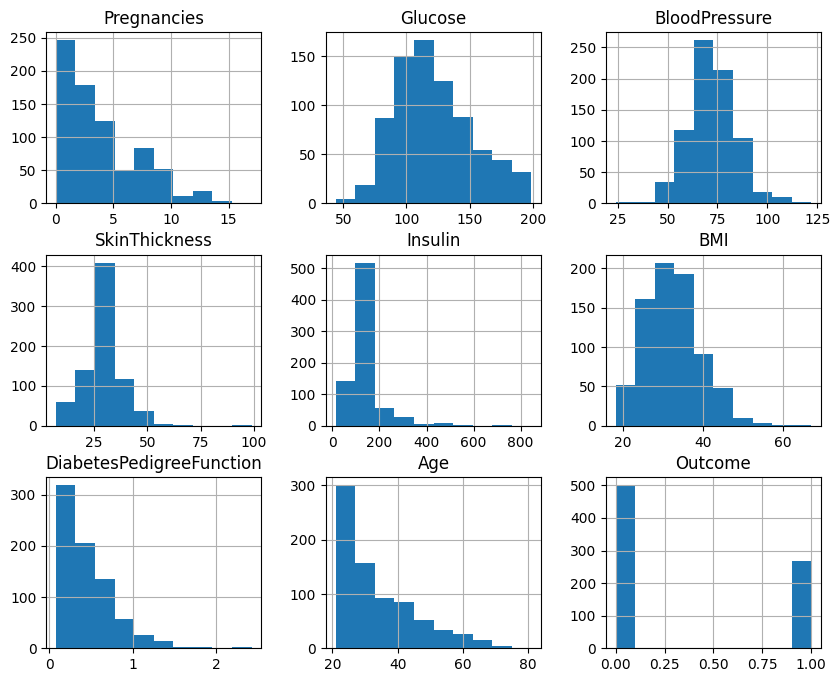

In [10]:
#Understand distribution(histogram)
import matplotlib.pyplot as plt
df.hist(figsize=(10,8))
plt.show()

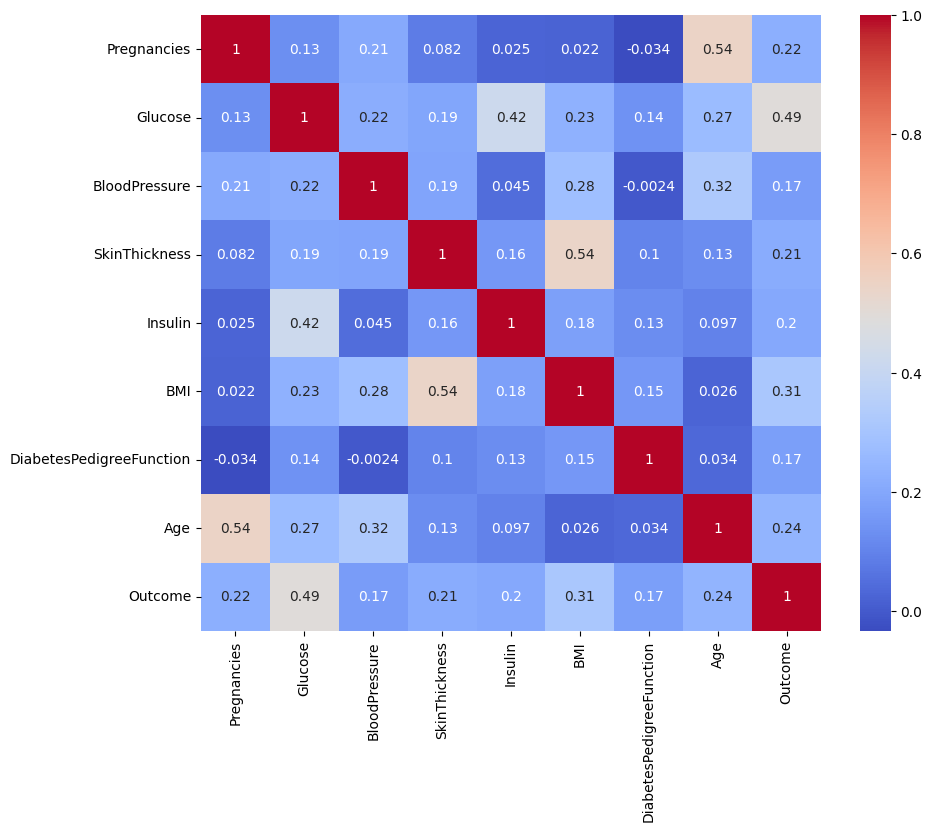

In [11]:
#Correlation(relationship between variables)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap = "coolwarm")
plt.show()

In [12]:
df.corr()["Outcome"].sort_values(ascending=False)

,Outcome
Outcome,1.000000
Glucose,0.492782
BMI,0.312038
Age,0.238356
Pregnancies,0.221898
SkinThickness,0.214873
Insulin,0.203790
DiabetesPedigreeFunction,0.173844
BloodPressure,0.165723


- **FEATURE ENGINEERING AND PREPROCESSING**

---



In [13]:
#feature and target split
x = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [14]:
x.shape

(768, 8)

In [15]:
y.shape

(768,)

In [16]:
#Train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train , y_test = train_test_split(x,y, test_size =0.2, random_state = 42)


In [20]:
x_train.shape

(614, 8)

In [21]:
x_test.shape

(154, 8)

In [22]:
y_train.shape

(614,)

In [23]:
y_test.shape

(154,)

In [24]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [25]:
x_train

array([[-0.52639686, -1.25688146, -0.01899526, ..., -0.00745016,
        -0.49073479, -1.03594038],
       [ 1.58804586, -0.32605067,  0.8081742 , ..., -0.59909194,
         2.41502991,  1.48710085],
       [-0.82846011,  0.57153617, -2.16963585, ..., -0.52694051,
         0.54916055, -0.94893896],
       ...,
       [ 1.8901091 , -0.69173419,  1.13904198, ...,  1.91177805,
         1.981245  ,  0.44308379],
       [-1.13052335,  0.63802409, -0.01899526, ...,  1.45000885,
        -0.78487662, -0.33992901],
       [-1.13052335,  0.10612077,  1.96621144, ..., -1.42161832,
        -0.61552223, -1.03594038]])

- **MODEL BUILDING**

---



In [26]:
#Training your first model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train, y_train)


LogisticRegression()

In [27]:
#Make Predictions
y_pred = model.predict(x_test)

In [28]:
y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1])

- **MODEL EVALUATION**

---



In [30]:
#Check accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.7532467532467533


In [31]:
#confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[82 17]
 [21 34]]


In [32]:
#check precision and recall
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



- **MODEL IMPROVEMENT**

---



In [33]:
# IMPROVE MODEL (CLASS WEIGHT)
model = LogisticRegression(class_weight="balanced")
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.70      0.75        99
           1       0.57      0.71      0.63        55

    accuracy                           0.70       154
   macro avg       0.69      0.70      0.69       154
weighted avg       0.72      0.70      0.71       154



- **ADVANCED MODEL - RANDOM FOREST**

---



In [36]:
#UPGRADE = TRY A BETTER MODEL
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state = 42)
rf.fit(x_train, y_train)

#predict
y_pred_rf = rf.predict(x_test)

In [37]:
#evaluate
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.80      0.79      0.79        99
           1       0.62      0.64      0.63        55

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



- **MODEL TUNING**

---



In [38]:
#TUNE RANDOM FOREST
rf = RandomForestClassifier(n_estimators=1200,
                            max_depth=5,
                            class_weight = 'balanced',
                            random_state=42)
rf.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5, n_estimators=1200,
                       random_state=42)

In [39]:
#predicting again
y_pred_rf = rf.predict(x_test)
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.89      0.72      0.79        99
           1       0.62      0.84      0.71        55

    accuracy                           0.76       154
   macro avg       0.75      0.78      0.75       154
weighted avg       0.79      0.76      0.76       154



In [40]:
rf.feature_importances_

array([0.05302652, 0.31892483, 0.03630384, 0.0619423 , 0.10641423,
       0.18278055, 0.07623656, 0.16437116])

In [41]:
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=df.drop("Outcome", axis=1).columns)
feature_importance.sort_values(ascending=False)

,0
Glucose,0.318925
BMI,0.182781
Age,0.164371
Insulin,0.106414
DiabetesPedigreeFunction,0.076237
SkinThickness,0.061942
Pregnancies,0.053027
BloodPressure,0.036304


In [44]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, x, y, cv=5)
print(scores.mean())

0.7604702487055428


#“The project aimed to predict diabetes using patient health data. Multiple models were tested, and performance was evaluated using recall due to the medical nature of the problem. A tuned Random Forest model achieved the best performance with recall of 0.84 for diabetic cases, reducing missed diagnoses.”


#CONCLUSION

---



##*“In this project, multiple models were implemented and evaluated, including Logistic Regression and Random Forest. Initial results showed moderate performance, particularly lower recall for diabetic cases. After applying class balancing and hyperparameter tuning, the Random Forest model achieved improved recall of 0.84, reducing missed diabetes cases. This makes the model more suitable for healthcare applications where identifying positive cases is critical.”*